# 1. Chrome-Dino Game Overview: 🦖 🦕

It is a classical game that was developed by Sebastien Gabriel, Alan Bettes, and Edward Jung in 2014, it was initally developed as an Easter game by Google

![Dino Game](Images/dino_game_demo.png)

the goal of this game is to navigate through the obstacles 🌵 and survive for the longest period possible, the longer you are alive the faster the game gets

**Our Goals**
-   Train an AI Agent that interacts with the environment of the game, navigate through the obstacles and achieve a good reasonable score `10,000` points
- Intrepret decisions taken by the AI Agent using `(XRL)` Explainable Reinforcement Learning techniques helps us understand why did the agent take that specific action in that given state
- Compare and Contrast Different Reinforcement Learning Techniques

# 2. Setting Up Environment for Reinforcement Learning

We need to get access to this game, one easy straightforward solution is to use ChromiumDriver, it is a `web driver` allows our program/code to communicate to browser easily, it is fundmentally the same as Hardware drivers such as `Printer Driver` that bridges the communication between software and the Printer hardware

**Workflow**

1. Set Up WebDriver
2. Wrapping Environment as a custom Environment in OpenAI `Gymnasium`

**1. Set Up WebDriver**

In [1]:
GAME_URL="chrome://dino/"
IMAGES_FOLDER="Images"

In [2]:
import os
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium import webdriver
from selenium.webdriver import Keys, ActionChains

service=Service("/usr/local/bin/chromedriver-linux64/chromedriver")
options=Options()
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service,options=options)
try:
    driver.get(GAME_URL)
except:
    pass
print("Title of webpage is :",driver.title)
print("="*100)
element_to_delete = driver.find_element(By.ID,"main-message")
driver.execute_script("arguments[0].style.display = 'none'; ",element_to_delete)
print("Taking screenshot...")
ActionChains(driver).send_keys(Keys.ARROW_UP).perform()
for _ in range(100):
    ActionChains(driver).send_keys(Keys.NULL).perform()

main_content = driver.find_element(By.CLASS_NAME,"runner-container")
image_path=os.path.join(IMAGES_FOLDER,"first_screenshot.png")
main_content.screenshot(image_path)
driver.quit()

Title of webpage is : chrome://dino/ - Dino game, press space to play
Taking screenshot...


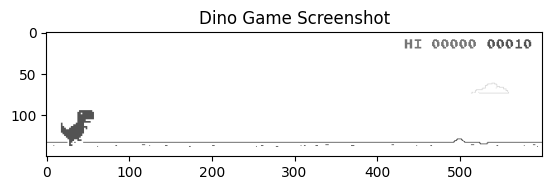

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as im

plt.title("Dino Game Screenshot")
plt.imshow(im.imread(image_path));

**2. Custom Environment**

**Gymnasium**
Requirements:
1. Observation space
2. Action space


In [95]:
AGENT_IMAGES_FOLDER="Agent_Images"

class DinoDriver:
    def __init__(self,service_url):
        service=Service(service_url)
        options=Options()
        options.add_argument("--no-sandbox")
        self.screenshoot_no=0
        self.driver = webdriver.Chrome(service=service,options=options)
        
    def GetDriver(self):
        return self.driver
    
    def StartGame(self):
        try:
            self.driver.get(GAME_URL)
        except:
            pass
            
        element_to_delete = self.driver.find_element(By.ID,"main-message")
        self.driver.execute_script("arguments[0].style.display = 'none'; ",element_to_delete)
        ActionChains(self.driver).send_keys(Keys.ARROW_UP).perform()
        for _ in range(100):
            ActionChains(self.driver).send_keys(Keys.NULL).perform()
            
        self.PauseGame()
        

        self.TakeScreenShot()

    def CheckGameStatus(self):
        isGameDone  = self.driver.execute_script("return runnerInstance.crashed;")
        return isGameDone
    
    def GetCurrentScore(self):
        CurrentScore = int(self.driver.execute_script("return runnerInstance.distanceMeter.digits.join('')"))
        return CurrentScore

    def TakeScreenShot(self):

        main_content = self.driver.find_element(By.CLASS_NAME,"runner-container")
        image_path=os.path.join(AGENT_IMAGES_FOLDER,f"{self.screenshoot_no}.png")
        main_content.screenshot(image_path)
        self.screenshoot_no+=1

    def GetLatestScreenShot(self):

        return im.imread(os.path.join(AGENT_IMAGES_FOLDER,f"{self.screenshoot_no-1}.png"))
    
    def PauseGame(self):
        self.driver.execute_script("runnerInstance.stop();")

    def ResumeGame(self):
        self.driver.execute_script("runnerInstance.play();")

    def ExecuteAction(self,key):
        self.ResumeGame()
        ActionChains(self.driver).send_keys(key).perform()
        self.TakeScreenShot()
        self.PauseGame()
        

    def _close_game(self):
        self.driver.quit()

SERVICE_URL="/usr/local/bin/chromedriver-linux64/chromedriver"
dino_driver = DinoDriver(SERVICE_URL)
dino_driver.StartGame()
print("current score of dino is ==> ",dino_driver.GetCurrentScore())

current score of dino is ==>  5


In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from selenium.webdriver import Keys, ActionChains
from typing import Optional

WIDTH_IMAGE=600
HEIGHT_IMAGE=150

class DinoEnv(gym.Env):
    def __init__(self, dino_driver):
        
        self.observation_space = spaces.Box(low=0,high=255, shape=(HEIGHT_IMAGE,WIDTH_IMAGE,3), dtype=np.uint8)
        self.action_space = spaces.Discrete(3) #Jump,Duck,Do nothing
        self.dino_driver = dino_driver

        #Mapping actions to actual keyboard keys
        self._action_to_key = {
            0:Keys.ARROW_UP,
            1:Keys.ARROW_DOWN,
            2:Keys.NULL #Basically do nothing
        }


    def _get_obs(self):
        """
        using private method, it takes internal observation and converts into required observation/state format

        this according to https://gymnasium.farama.org/introduction/create_custom_env/
        helps us to apply (Do not repeat yourself principle)

        Note this function is not callable from outside the Class as it is a private method/function
        """
        return self.dino_driver.GetLatestScreenShot()
    
    def _get_info(self):
        """
        Returns Score/Time
        """

        return {"Current Score":self.dino_driver.GetCurrentScore()}
    
    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """
        takes seed, options

        returns State, Info tuple
        """

        super().reset(seed=seed)



        #start the game via pressing space
        self.dino_driver.StartGame()

        #Initalise screenshot image

        observation = self._get_obs()
        info = self._get_info()

        return observation, info

    def _reward_function(self,done,info):
        reward=0
        if not done:
            reward+=0.1 * info["Current Score"]
        else:
            reward = -1000

        return reward
    
    def step(self, action):
        """
        takes action int, returns observation, reward, done, info
        """
        key = self._action_to_key[action]
        self.dino_driver.ExecuteAction(key)

        done = self.dino_driver.CheckGameStatus()
        observation = self._get_obs()
        info = self._get_info()
        reward=self._reward_function(done,info)

        return observation, reward, done ,info
    

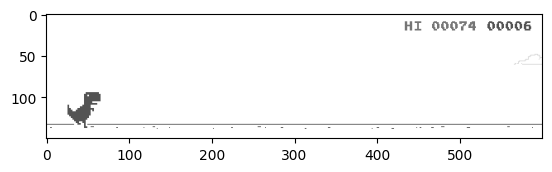

In [173]:
dino_env = DinoEnv(dino_driver)
state, info = dino_env.reset()
plt.imshow(state)

reward is  0.5
reward is  0.5
reward is  0.6000000000000001
reward is  0.7000000000000001
reward is  0.8


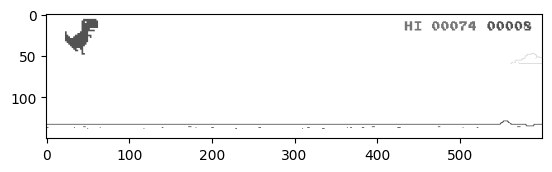

In [161]:
for _ in range(5):
    observation, reward, done ,info= dino_env.step(0)
    plt.imshow(observation)
    print("reward is ",reward)

# 3. Data Preprocessing

we need to apply the following transformations

1. Grayscale images
2. DownScaling

In [179]:
from gymnasium.wrappers import GrayscaleObservation

dino_env = GrayscaleObservation(dino_env, keep_dim=True)

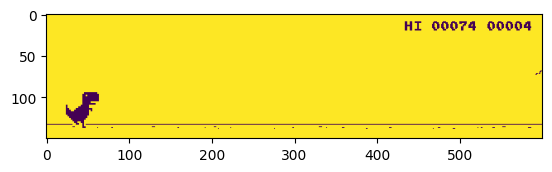

In [180]:
state, info = dino_env.reset()
plt.imshow(state)

In [181]:
state.shape

(150, 600, 1)

In [176]:
state.max()

np.float32(1.0)